# H-Reflex Workbook — Multi-Recording Combined Analysis

This notebook loads **two or more recordings** of the same experimental session and treats them
as a single unified dataset for recruitment-curve analysis.  The typical use-case is interleaved
amplitude steps: Recording 1 covers (0.20, 0.30, 0.40 … mA) and Recording 2 covers
(0.25, 0.35, 0.45 … mA); combining them gives full resolution across the recruitment range.

## Quick-run guide
1. Edit `DIRECTORIES` in the **Configuration** cell to point at your two (or more) sessions.
2. Adjust `m_wave_start/end` and `h_wave_start/end` if needed.
3. Run all cells top-to-bottom.
4. The **viewer** shows averaged waveforms per amplitude from all recordings combined.
5. The **recruitment-curve** cell plots raw and normalized 6mm / 9mm curves.

> **Note:** Each recording is processed independently (its own ADC1 detection, MessageCenter
> parsing, and trigger matching).  Only after matching are trials pooled by amplitude and averaged.

## Imports

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label
from open_ephys.analysis import Session
from scipy.signal import butter, lfilter
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator

from helpers import *

DEFAULT_PROTOCOL = PROTOCOL_OFFLINE
print('Imports OK')

Imports OK


## Configuration
Edit `DIRECTORIES` to list every recording you want to combine.
All other parameters below mirror the single-recording workbook.

In [2]:
# ============================================================
#  CONFIGURATION — edit these to point at your recordings
# ============================================================
DIRECTORIES = [
    '2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002',
    '2-17-2026/SEQ-3-1mm_Electrode_Placement__Test2_2026-02-17_14-42-32_003',
]

# Record node selection (offline = index 1, Node 111)
RECORD_NODE_INDEX = 1
RECORD_NODE_NAME  = 'Record Node 111'

# --- Signal processing ---
LOWCUT  = 100    # Hz  bandpass low edge
HIGHCUT = 1000   # Hz  bandpass high edge

# --- Peri-stimulus window ---
PRE_EVENT_TIME    = 5      # ms before stim onset to include
POST_EVENT_TIME   = 20     # ms after stim onset to include
STIM_THRESHOLD    = 0.01   # ADC1 threshold to detect pulse onset (V)
OFFSTIM_THRESHOLD = 0.41   # ADC1 threshold to detect pulse end (V)

# --- M / H wave detection windows (ms, relative to stim onset) ---
m_wave_start, m_wave_end = 2.0, 5.5
h_wave_start, h_wave_end = 7.0, 11.0

print(f'Recordings to combine: {len(DIRECTORIES)}')
for d in DIRECTORIES:
    print(f'  {d}')

Recordings to combine: 2
  2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002
  2-17-2026/SEQ-3-1mm_Electrode_Placement__Test2_2026-02-17_14-42-32_003


## `process_recording()` — per-recording extraction function

This function encapsulates the full single-recording pipeline:
- Load continuous data and bandpass-filter all four differential EMG channels.
- Detect stim onsets from sync events + ADC1 threshold crossing.
- Parse MessageCenter to identify amplitude groups and trigger timestamps.
- Match each trigger to its closest peri-stim segment (within 100 ms tolerance).

**Returns** a dict `{ amplitude_mA: [(t_ms, ch_windows, stim_end_ms), ...] }` —
one entry per matched trial, ready to be pooled across recordings.

In [3]:
def process_recording(directory,
                      record_node_index=RECORD_NODE_INDEX,
                      record_node_name=RECORD_NODE_NAME,
                      lowcut=LOWCUT, highcut=HIGHCUT,
                      pre_event_time=PRE_EVENT_TIME,
                      post_event_time=POST_EVENT_TIME,
                      stim_threshold=STIM_THRESHOLD,
                      offstim_threshold=OFFSTIM_THRESHOLD):
    """
    Load one Open Ephys recording, filter EMG, extract peri-stim windows,
    parse MessageCenter amplitude groups, and match triggers to segments.

    Returns
    -------
    matched_by_amp : dict
        { float_amp_mA : [(t_ms_array, ch_windows_dict, stim_end_ms), ...] }
        Trials from multiple recordings with the same amplitude can be
        concatenated and averaged together.
    """
    print(f'\nLoading: {directory}')
    session   = Session(directory)
    recording = session.recordnodes[record_node_index].recordings[0]

    dir_str  = recording.directory
    parts    = dir_str.split(os.sep)
    rn_name  = parts[-3]
    exp_name = parts[-2]
    rec_name = parts[-1]
    print(f'  -> {rn_name}/{exp_name}/{rec_name}')

    # ── Continuous data ──────────────────────────────────────────────────
    stream      = recording.continuous[0]
    sample_rate = stream.metadata.sample_rate
    timestamps  = stream.timestamps
    data        = stream.get_samples(start_sample_index=0,
                                     end_sample_index=len(timestamps))
    print(f'  Sample rate: {sample_rate} Hz | Shape: {data.shape}')

    # ── Channel layout: ['CH1','CH5','CH7','CH8','CH10','CH12','ADC1'] ──
    #   indices:           0      1     2     3     4      5      6
    emg5_raw  = data[:, 1]
    emg7_raw  = data[:, 2]
    emg10_raw = data[:, 4]
    emg12_raw = data[:, 5]

    b_filt, a_filt = butter(2,
                            np.array([lowcut, highcut]) / (sample_rate / 2),
                            btype='bandpass')

    ch_signals = {
        '1mm': lfilter(b_filt, a_filt, emg7_raw  - emg5_raw),
        '2mm': lfilter(b_filt, a_filt, emg12_raw - emg10_raw),
        '6mm': lfilter(b_filt, a_filt, emg10_raw - emg7_raw),
        '9mm': lfilter(b_filt, a_filt, emg12_raw - emg5_raw),
    }

    adc1_det = np.abs(data[:, 6])

    # ── Sync events ──────────────────────────────────────────────────────
    events      = recording.events
    sync_events = events[
        (events.line == 1) & (events.processor_id == 100) &
        (events.stream_name == 'Rhythm Data') & (events.state == 1)
    ]
    sync_timestamps = sync_events['timestamp'].to_numpy()
    print(f'  Sync events: {len(sync_timestamps)}')

    # ── Extract peri-stimulus segments ───────────────────────────────────
    peri_stim_segments    = []
    peri_stim_start_times = []

    for stamp in sync_timestamps:
        i0 = np.searchsorted(timestamps, stamp - 0.00003)
        i1 = np.searchsorted(timestamps, stamp + 0.010)
        if i0 < 0 or i1 > len(timestamps):
            continue

        above = np.where(adc1_det[i0:i1] > stim_threshold)[0]
        if len(above) == 0:
            continue

        stim_idx  = i0 + above[0]
        stim_time = timestamps[stim_idx]

        idx_pre  = int(stim_idx - (pre_event_time  / 1000) * sample_rate)
        idx_post = int(stim_idx + (post_event_time / 1000) * sample_rate)
        if idx_pre < 0 or idx_post > len(timestamps):
            continue

        t_zeroed  = timestamps[idx_pre:idx_post] - stim_time
        adc1_win  = adc1_det[idx_pre:idx_post]
        post_mask = t_zeroed >= 0
        below     = np.where(adc1_win[post_mask] < offstim_threshold)[0]
        stim_end_ms = (float(t_zeroed[post_mask][below[0]] * 1000)
                       if len(below) > 0 else float(post_event_time))

        ch_windows = {lbl: ch_signals[lbl][idx_pre:idx_post] for lbl in ch_signals}
        peri_stim_segments.append((t_zeroed * 1000, ch_windows, stim_end_ms))
        peri_stim_start_times.append(stim_time)

    print(f'  Peri-stim segments extracted: {len(peri_stim_segments)}')

    # ── Parse MessageCenter amplitude groups ─────────────────────────────
    message_entries = load_message_center_events(
        dir_str, rn_name, exp_name, rec_name)

    trig_re = re.compile(r'RHDCONTROL TRIGGER')
    # Matches "Starting at 0.25 mA" OR "Starting 0.25 mA"
    amp_re  = re.compile(r'starting(?: at)? (\d+\.?\d*)\s*mA', re.IGNORECASE)

    stim_groups   = []
    current_group = []
    current_amp   = None

    for t, msg in message_entries:
        if amp_re.search(msg):
            if current_amp is not None and current_group:
                stim_groups.append((current_amp, current_group))
            current_amp   = float(amp_re.search(msg).group(1))
            current_group = []
        elif trig_re.search(msg) and current_amp is not None:
            current_group.append(t)

    if current_amp is not None and current_group:
        stim_groups.append((current_amp, current_group))

    # Merge duplicate amplitudes within this recording
    _merged = {}
    for _amp, _trigs in stim_groups:
        _merged.setdefault(_amp, []).extend(_trigs)
    stim_groups = sorted(_merged.items())
    print(f'  Amplitude groups: {[f"{a:.2f}mA" for a, _ in stim_groups]}')

    # ── Match trigger times -> peri-stim segments ────────────────────────
    # Matching is done WITHIN this recording only: MessageCenter timestamps
    # and sync event timestamps share the same absolute time domain.
    # Cross-recording pooling happens after this function returns.
    seg_arr        = np.array(peri_stim_start_times)
    matched_by_amp = defaultdict(list)

    for stim_amp, trig_times in stim_groups:
        used = set()
        for trig_time in trig_times:
            if len(seg_arr) == 0:
                continue
            idx_m = np.argmin(np.abs(seg_arr - trig_time))
            if abs(seg_arr[idx_m] - trig_time) >= 0.1:  # >100 ms -> no match
                continue
            if idx_m in used:
                continue
            used.add(idx_m)
            t_ms, ch_wins, stim_end = peri_stim_segments[idx_m]
            matched_by_amp[stim_amp].append((t_ms, ch_wins, stim_end))

    n_matched = sum(len(v) for v in matched_by_amp.values())
    print(f'  Matched trials: {n_matched} across {len(matched_by_amp)} amplitudes')

    return dict(matched_by_amp)


print('process_recording() defined.')

process_recording() defined.


## Load and combine all recordings
Each recording is processed independently.  Trials from different recordings that share
the same amplitude are pooled into a single list — effectively treating them as one session.

In [4]:
# Pool trials across all recordings, grouped by stimulation amplitude
all_trials = defaultdict(list)   # { float_amp : [(t_ms, ch_wins, stim_end), ...] }

for directory in DIRECTORIES:
    rec_trials = process_recording(directory)
    for amp, trials in rec_trials.items():
        all_trials[amp].extend(trials)

print(f"\n{'='*55}")
print(f"COMBINED: {len(all_trials)} unique amplitudes from "
      f"{len(DIRECTORIES)} recordings")
print(f"{'='*55}")
for amp in sorted(all_trials.keys()):
    print(f"  {amp:.2f} mA  ->  {len(all_trials[amp])} trials")


Loading: 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002
  -> Record Node 111/experiment1/recording1
  Sample rate: 5000.0 Hz | Shape: (12537898, 7)
  Sync events: 615
  Peri-stim segments extracted: 615
Loaded 653 MessageCenter entries from 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002\Record Node 111\experiment1\recording1\events\MessageCenter
  Amplitude groups: ['0.05mA', '0.10mA', '0.15mA', '0.20mA', '0.25mA', '0.30mA', '0.35mA', '0.40mA', '0.45mA', '0.50mA', '0.60mA', '0.70mA', '0.80mA', '0.90mA', '1.00mA', '1.10mA', '1.20mA', '1.30mA', '1.40mA', '1.50mA', '1.60mA', '1.70mA', '1.80mA', '1.90mA', '2.00mA', '2.10mA', '2.20mA', '2.30mA', '2.40mA', '2.50mA', '2.60mA', '2.70mA', '2.80mA', '2.90mA', '3.00mA']
  Matched trials: 615 across 35 amplitudes

Loading: 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test2_2026-02-17_14-42-32_003
  -> Record Node 111/experiment1/recording1
  Sample rate: 5000.0 Hz | Shape: (3397230, 7)
  Sync events: 15

## Build averaged groups and detect M / H peaks
For every amplitude, all matched trials (from all recordings) are averaged together.
M- and H-wave peaks are detected on the 1mm, 6mm, and 9mm channel averages.

In [5]:
# Channel display order and colors (label, color)
CHANNELS = [
    ('1mm', 'purple'),
    ('2mm', 'green'),
    ('6mm', 'blue'),
    ('9mm', 'orange'),
]

stim_intensities  = []
m_wave_peaks      = []
h_wave_peaks      = []
m_wave_peaks_6mm  = []
h_wave_peaks_6mm  = []
m_wave_peaks_9mm  = []
h_wave_peaks_9mm  = []
groups_list       = []   # fed into viewer and recruitment curves

for stim_amp in sorted(all_trials.keys()):
    trials     = all_trials[stim_amp]
    ch_acc     = defaultdict(list)
    end_ms_acc = []
    time_ms_ref = None

    for t_ms, ch_wins, stim_end in trials:
        if time_ms_ref is None:
            time_ms_ref = t_ms
        end_ms_acc.append(stim_end)
        for label in ch_wins:
            ch_acc[label].append(ch_wins[label])

    if time_ms_ref is None:
        continue

    # Average each channel across all pooled trials
    ch_avgs = {}
    for label, _ in CHANNELS:
        ws = ch_acc.get(label, [])
        if ws:
            min_len = min(len(w) for w in ws)
            ch_avgs[label] = np.mean([w[:min_len] for w in ws], axis=0)
        else:
            ch_avgs[label] = None

    # Trim everything to the shortest valid length
    valid_lens = [len(v) for v in ch_avgs.values() if v is not None]
    if not valid_lens:
        continue
    min_len = min(valid_lens)
    t_ms    = time_ms_ref[:min_len]
    ch_avgs = {k: (v[:min_len] if v is not None else None)
               for k, v in ch_avgs.items()}
    avg_end  = float(np.mean(end_ms_acc)) if end_ms_acc else 0.0
    n_trials = len(trials)

    # M / H peak detection
    ref_1mm = ch_avgs.get('1mm')
    ref_6mm = ch_avgs.get('6mm')
    ref_9mm = ch_avgs.get('9mm')

    if ref_1mm is not None:
        stim_intensities.append(stim_amp)
        m_mask = (t_ms >= m_wave_start) & (t_ms <= m_wave_end)
        h_mask = (t_ms >= h_wave_start) & (t_ms <= h_wave_end)
        m_wave_peaks.append(
            float(ref_1mm[m_mask].max()) if np.any(m_mask) else 0.0)
        h_wave_peaks.append(
            float(ref_1mm[h_mask].max()) if np.any(h_mask) else 0.0)
        m_wave_peaks_6mm.append(
            float(np.abs(ref_6mm[m_mask]).max())
            if ref_6mm is not None and np.any(m_mask) else 0.0)
        h_wave_peaks_6mm.append(
            float(np.abs(ref_6mm[h_mask]).max())
            if ref_6mm is not None and np.any(h_mask) else 0.0)
        m_wave_peaks_9mm.append(
            float(np.abs(ref_9mm[m_mask]).max())
            if ref_9mm is not None and np.any(m_mask) else 0.0)
        h_wave_peaks_9mm.append(
            float(np.abs(ref_9mm[h_mask]).max())
            if ref_9mm is not None and np.any(h_mask) else 0.0)

    groups_list.append({
        'amp':     stim_amp,
        'time_ms': t_ms,
        'ch_avgs': ch_avgs,
        'avg_end': avg_end,
        'n_trials': n_trials,
    })

print(f'Built {len(groups_list)} amplitude groups.')
for g in groups_list:
    print(f"  {g['amp']:.2f} mA  n={g['n_trials']}")

Built 43 amplitude groups.
  0.05 mA  n=9
  0.10 mA  n=14
  0.15 mA  n=34
  0.20 mA  n=11
  0.25 mA  n=28
  0.30 mA  n=7
  0.35 mA  n=39
  0.40 mA  n=5
  0.45 mA  n=19
  0.50 mA  n=10
  0.55 mA  n=10
  0.60 mA  n=14
  0.65 mA  n=7
  0.70 mA  n=15
  0.75 mA  n=6
  0.80 mA  n=13
  0.85 mA  n=8
  0.90 mA  n=10
  0.95 mA  n=13
  1.00 mA  n=18
  1.05 mA  n=15
  1.10 mA  n=18
  1.15 mA  n=13
  1.20 mA  n=14
  1.25 mA  n=7
  1.30 mA  n=17
  1.40 mA  n=22
  1.50 mA  n=19
  1.60 mA  n=18
  1.70 mA  n=24
  1.80 mA  n=21
  1.90 mA  n=13
  2.00 mA  n=15
  2.10 mA  n=25
  2.20 mA  n=24
  2.30 mA  n=13
  2.40 mA  n=38
  2.50 mA  n=20
  2.60 mA  n=48
  2.70 mA  n=22
  2.80 mA  n=20
  2.90 mA  n=28
  3.00 mA  n=23


## Interactive paged viewer
Averaged waveforms from the combined dataset, 4 per page.
The trial count `n=` in each title reflects trials from **all** recordings pooled.

In [6]:
if not groups_list:
    print('No valid groups found. Check process_recording output and '
          'MessageCenter parsing.')
else:
    n_per_page   = 4
    pages        = [groups_list[i:i + n_per_page]
                    for i in range(0, len(groups_list), n_per_page)]
    current_page = {'idx': 0}
    print(f'Prepared {len(groups_list)} groups across {len(pages)} pages.')

    out         = Output()
    amp_dd      = Dropdown(options=[], description='View:')
    zoom_btn    = Button(description='View', button_style='info')
    active_conn = {'cid': None, 'canvas': None}

    def _draw(ax, g, fontsize=8):
        """Draw averaged traces + shaded regions for one amplitude group."""
        t = g['time_ms']
        for label, color in CHANNELS:
            avg = g['ch_avgs'].get(label)
            if avg is not None:
                ax.plot(t, avg, color=color, linewidth=1.5, label=label)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
        ax.axvspan(0,            g['avg_end'],   color='red',        alpha=0.20)
        ax.axvspan(m_wave_start, m_wave_end,     color='lightblue',  alpha=0.30)
        ax.axvspan(h_wave_start, h_wave_end,     color='lightgreen', alpha=0.30)
        ax.set_xlabel('(ms)', fontsize=14)
        ax.set_ylabel('(\u03bcV)', fontsize=14)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.5))
        ax.grid(True, which='both', alpha=0.3)
        try:
            ax.set_xlim(np.min(t), np.max(t))
        except Exception:
            pass
        ax.legend(fontsize=fontsize, loc='upper right', framealpha=0.8)

    def show_zoom(group):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(1, 1, figsize=(9, 5))
            _draw(ax, group, fontsize=9)
            ax.set_title(
                f"Stim Amp: {group['amp']:.2f} mA | "
                f"n={group['n_trials']} (combined)", fontsize=11)
            plt.tight_layout()
            plt.show()
            back_btn = Button(description='Back to grid', button_style='info')
            def on_back(b): plot_page(current_page['idx'])
            back_btn.on_click(on_back)
            display(back_btn)

    def plot_page(page_idx):
        try:
            if active_conn['cid'] is not None and active_conn['canvas'] is not None:
                active_conn['canvas'].mpl_disconnect(active_conn['cid'])
                active_conn['cid'] = None
                active_conn['canvas'] = None
        except Exception:
            pass
        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n    = len(page)
            fig, axs = plt.subplots(2, 2, figsize=(13, 8))
            axs = axs.flatten()

            amp_dd.options = [(f"{g['amp']:.2f} mA", idx)
                              for idx, g in enumerate(page)]
            if amp_dd.options:
                amp_dd.value = 0

            for j in range(4):
                if j < n:
                    _draw(axs[j], page[j], fontsize=7)
                    axs[j].set_title(
                        f"Stim Amp: {page[j]['amp']:.2f} mA | "
                        f"n={page[j]['n_trials']} (combined)", fontsize=14)
                else:
                    axs[j].axis('off')
            plt.tight_layout()
            plt.show()

            try:
                def on_click(event):
                    if event.inaxes is None:
                        return
                    for k, ax in enumerate(axs):
                        if event.inaxes == ax and k < n:
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k])
                            else:
                                amp_dd.value = k
                            break
                cid = fig.canvas.mpl_connect('button_press_event', on_click)
                active_conn['cid']    = cid
                active_conn['canvas'] = fig.canvas
            except Exception:
                pass

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            plot_page(current_page['idx'])

    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            plot_page(current_page['idx'])

    def on_dd_change(change):
        if 'new' in change:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_zoom(b):
        try:
            page = pages[current_page['idx']]
            if 0 <= int(amp_dd.value) < len(page):
                show_zoom(page[int(amp_dd.value)])
        except Exception:
            print('Could not zoom selected group.')

    next_btn = Button(description='Next',     button_style='primary')
    prev_btn = Button(description='Previous')
    page_dd  = Dropdown(
        options=[(f'Page {i+1}', i) for i in range(len(pages))],
        description='Page:')

    next_btn.on_click(on_next)
    prev_btn.on_click(on_prev)
    page_dd.observe(on_dd_change, names='value')
    zoom_btn.on_click(on_zoom)

    display(VBox([HBox([prev_btn, next_btn, page_dd, Label(' '), amp_dd, zoom_btn]),
                  out]))
    plot_page(0)

Prepared 43 groups across 11 pages.


## Recruitment curves — combined dataset
Raw and normalized (% M_max) recruitment curves for the 6 mm and 9 mm electrode configurations,
built from all recordings combined.

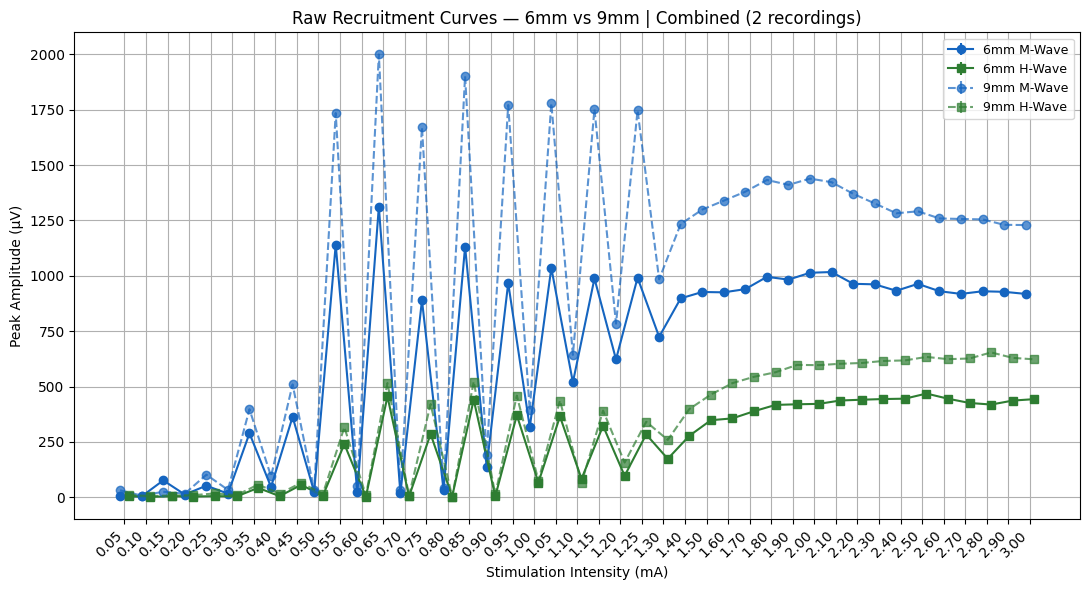

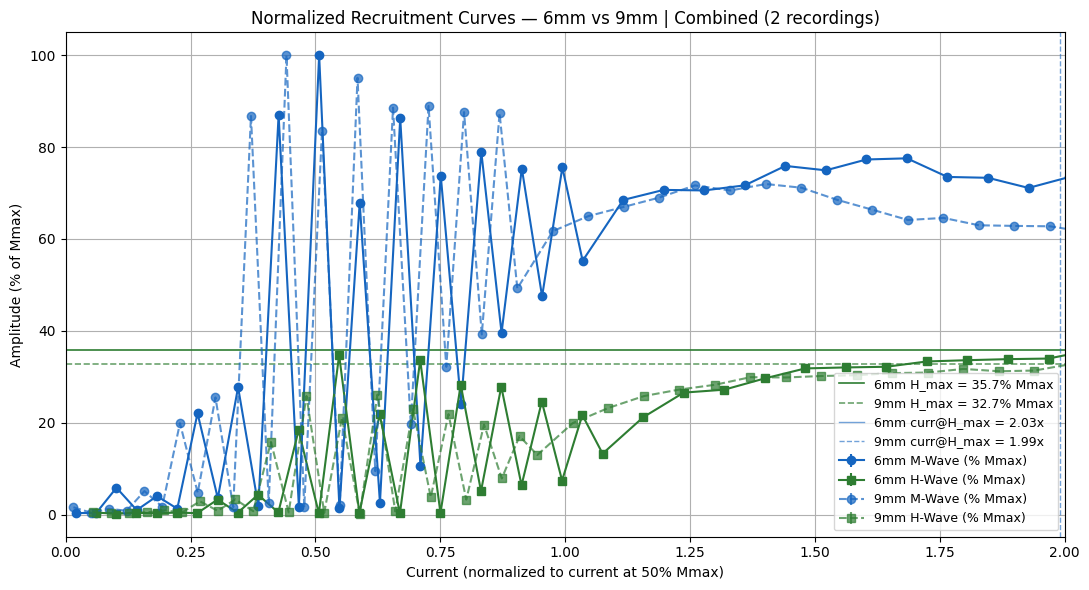

c50_6mm = 1.232 mA   c50_9mm = 1.407 mA
H_max_6mm = 35.7% Mmax   H_max_9mm = 32.7% Mmax


In [7]:
def _recruitment_stats(stim_ints, m_peaks, h_peaks):
    m_d, h_d = defaultdict(list), defaultdict(list)
    for amp, m, h in zip(stim_ints, m_peaks, h_peaks):
        m_d[amp].append(abs(m))
        h_d[amp].append(abs(h))
    amps    = sorted(set(stim_ints))
    m_means = np.array([np.mean(m_d[a]) for a in amps])
    h_means = np.array([np.mean(h_d[a]) for a in amps])
    m_sems  = np.array([stats.sem(m_d[a]) if len(m_d[a]) > 1 else 0.0
                        for a in amps])
    h_sems  = np.array([stats.sem(h_d[a]) if len(h_d[a]) > 1 else 0.0
                        for a in amps])
    return amps, m_means, h_means, m_sems, h_sems


def _normalize_recruitment(amps, m_means, h_means, m_sems, h_sems):
    from scipy.interpolate import interp1d
    M_max = np.max(m_means) if np.max(m_means) > 0 else 1.0
    m_n   = (m_means / M_max) * 100
    h_n   = (h_means / M_max) * 100
    ms_n  = (m_sems  / M_max) * 100
    hs_n  = (h_sems  / M_max) * 100
    try:
        f50 = interp1d(m_n, amps, kind='linear',
                       bounds_error=False, fill_value='extrapolate')
        c50 = float(f50(50))
    except Exception:
        c50 = amps[int(np.argmax(m_n >= 50))]
    if c50 == 0:
        c50 = 1.0
    norm_curr = np.array(amps) / c50
    return m_n, h_n, ms_n, hs_n, norm_curr, c50


# ── Build stats ──────────────────────────────────────────────────────────
amps_6mm, mm_6mm, hm_6mm, ms_6mm, hs_6mm = _recruitment_stats(
    stim_intensities, m_wave_peaks_6mm, h_wave_peaks_6mm)
amps_9mm, mm_9mm, hm_9mm, ms_9mm, hs_9mm = _recruitment_stats(
    stim_intensities, m_wave_peaks_9mm, h_wave_peaks_9mm)

mn_6mm, hn_6mm, msn_6mm, hsn_6mm, nc_6mm, c50_6mm = _normalize_recruitment(
    amps_6mm, mm_6mm, hm_6mm, ms_6mm, hs_6mm)
mn_9mm, hn_9mm, msn_9mm, hsn_9mm, nc_9mm, c50_9mm = _normalize_recruitment(
    amps_9mm, mm_9mm, hm_9mm, ms_9mm, hs_9mm)

CM = '#1565C0'   # blue  – M-wave
CH = '#2E7D32'   # green – H-wave
title_suffix = f'Combined ({len(DIRECTORIES)} recordings)'

# ── Plot 1: Raw amplitude recruitment curves ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

pos_6mm = np.arange(len(amps_6mm))
pos_9mm = np.arange(len(amps_9mm))

ax.errorbar(pos_6mm - 0.2, mm_6mm, yerr=ms_6mm,
            fmt='o-',  color=CM, label='6mm M-Wave')
ax.errorbar(pos_6mm + 0.2, hm_6mm, yerr=hs_6mm,
            fmt='s-',  color=CH, label='6mm H-Wave')
ax.errorbar(pos_9mm - 0.2, mm_9mm, yerr=ms_9mm,
            fmt='o--', color=CM, label='9mm M-Wave', alpha=0.7)
ax.errorbar(pos_9mm + 0.2, hm_9mm, yerr=hs_9mm,
            fmt='s--', color=CH, label='9mm H-Wave', alpha=0.7)

ax.set_xticks(pos_6mm)
ax.set_xticklabels([f'{a:.2f}' for a in amps_6mm], rotation=45, ha='right')
ax.set_xlabel('Stimulation Intensity (mA)')
ax.set_ylabel('Peak Amplitude (\u03bcV)')
ax.set_title(f'Raw Recruitment Curves — 6mm vs 9mm | {title_suffix}')
ax.grid(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 2: Normalized recruitment curves ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.errorbar(nc_6mm - 0.02, mn_6mm, yerr=msn_6mm, fmt='o-',
            color=CM, label='6mm M-Wave (% Mmax)')
ax.errorbar(nc_6mm + 0.02, hn_6mm, yerr=hsn_6mm, fmt='s-',
            color=CH, label='6mm H-Wave (% Mmax)')
ax.errorbar(nc_9mm - 0.02, mn_9mm, yerr=msn_9mm, fmt='o--',
            color=CM, label='9mm M-Wave (% Mmax)', alpha=0.7)
ax.errorbar(nc_9mm + 0.02, hn_9mm, yerr=hsn_9mm, fmt='s--',
            color=CH, label='9mm H-Wave (% Mmax)', alpha=0.7)

H_max_6mm = np.max(hn_6mm)
H_max_9mm = np.max(hn_9mm)
ax.axhline(H_max_6mm, color=CH, linestyle='-',  linewidth=1.2,
           label=f'6mm H_max = {H_max_6mm:.1f}% Mmax')
ax.axhline(H_max_9mm, color=CH, linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'9mm H_max = {H_max_9mm:.1f}% Mmax')

idx6 = int(np.argmax(hn_6mm))
idx9 = int(np.argmax(hn_9mm))
ax.axvline(nc_6mm[idx6], color=CM, linestyle='-',  linewidth=1, alpha=0.6,
           label=f'6mm curr@H_max = {nc_6mm[idx6]:.2f}x')
ax.axvline(nc_9mm[idx9], color=CM, linestyle='--', linewidth=1, alpha=0.6,
           label=f'9mm curr@H_max = {nc_9mm[idx9]:.2f}x')

ax.set_xlabel('Current (normalized to current at 50% Mmax)')
ax.set_ylabel('Amplitude (% of Mmax)')
ax.set_title(f'Normalized Recruitment Curves — 6mm vs 9mm | {title_suffix}')
ax.set_xlim(left=0, right=2)
ax.grid(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'c50_6mm = {c50_6mm:.3f} mA   c50_9mm = {c50_9mm:.3f} mA')
print(f'H_max_6mm = {H_max_6mm:.1f}% Mmax   H_max_9mm = {H_max_9mm:.1f}% Mmax')